# Model 1 -- Scotogenic Ma: radiative neutrino mass with dark matter

E. Ma, *Phys. Rev. D* **73**, 077301 (2006), hep-ph/0601225.


The scotogenic model generates neutrino masses **radiatively**, at one loop, instead of at tree level. An inert scalar doublet and three right-handed neutrinos are added, all odd under an exactly conserved $Z_2$ symmetry that the Standard Model fields do not carry. That symmetry forbids a tree-level neutrino mass, forces the mass to appear first at one loop through the new Yukawa couplings and scalar quartics, and simultaneously stabilizes the lightest $Z_2$-odd state as a dark matter candidate -- neutrino mass and dark matter share a common origin by construction.

**What this notebook does.** BSMScanner separates *what a model is* (a declarative YAML specification: parameters, priors, derived quantities, observables, validity conditions, likelihoods) from *how it is scanned* (one of several interchangeable search engines). This notebook loads the model below, runs a small, fast scan live so you can see the mechanics end to end, and then loads the matched-budget, fixed-seed comparison across all four engines from the companion paper's benchmark study, together with its best-fit / allowed-region result and figure. The live demo uses a short budget and an illustrative seed — it is not the published comparison, and is not expected to reproduce it exactly.


## 1. Load the framework and the model

In [1]:
import sys, pathlib
REPO_ROOT = pathlib.Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT / "python"))

import pandas as pd
from bsm_scanner import load_model, compile_model, run_scan
import bsm_scanner

print("bsm_scanner", bsm_scanner.__version__)
print("repo root  :", REPO_ROOT)

bsm_scanner 0.1.2
repo root  : /sessions/rcw-012reqeed7ksc6e9zagwhruw/mnt/BSMScanner


## 2. The model specification

Every scanned parameter, its prior, and its range come straight out of the model's YAML file (`../models/scotogenic_ma/model_no.yaml`); nothing here is hand-written Python.

In [2]:
model = load_model("../models/scotogenic_ma/model_no.yaml")
print("model    :", model.metadata.name)
print("params   :", len(model.parameters), "scanned")
print("theory checks:", len(model.theory_checks))
print("likelihood terms:", len(model.likelihoods))

pd.DataFrame(
    [{"name": p.name, "prior": p.prior.value, "lower": p.lower, "upper": p.upper, "default": p.default}
     for p in model.parameters]
)

model    : scotogenic_ma_normal
params   : 26 scanned
theory checks: 5
likelihood terms: 7


,name,prior,lower,upper,default
0,m_eta_sq,log,10000.00000,4000000.00,1.000000e+05
1,lambda2,log,0.00001,4.00,1.000000e-01
2,lambda3,flat,-4.00000,4.00,2.000000e-01
3,lambda4,flat,-4.00000,4.00,-1.000000e-01
4,lambda5,signed_log,-0.01000,0.01,1.000000e-08
5,MN1,log,10.00000,100000.00,9.000000e+02
6,MN2,log,10.00000,100000.00,1.400000e+03
7,MN3,log,10.00000,100000.00,2.600000e+03
8,he1_re,signed_log,-3.00000,3.00,1.800000e-02
9,he1_im,signed_log,-3.00000,3.00,4.000000e-03


Likelihood terms declared on the model:

In [3]:
pd.DataFrame(
    [{"name": t.name, "kind": t.kind.value, "observable": t.observable} for t in model.likelihoods]
)

,name,kind,observable
0,s12_nufit,table_lookup,s12
1,s13_nufit,table_lookup,s13
2,s23_nufit,table_lookup,s23
3,delta_cp_nufit,table_lookup,deltaCP_deg
4,dm21_nufit,table_lookup,log10_dm21
5,dm3l_nufit,table_lookup,dm3l_meV
6,sum_mnu_limit,hard_cut,sum_m


For reference, here is the parameter block exactly as written in the YAML (this is the entire declarative input the physics below is built from):

In [4]:
print(pathlib.Path("../models/scotogenic_ma/parameters.yaml").read_text())

parameters:
- {name: m_eta_sq, value_type: real, scan: true, lower: 10000.0, upper: 4000000.0, default: 100000.0, prior: log, description: Inert-doublet quadratic mass parameter in GeV^2.}
- {name: lambda2, value_type: real, scan: true, lower: 0.00001, upper: 4.0, default: 0.1, prior: log, description: Inert-doublet self quartic.}
- {name: lambda3, value_type: real, scan: true, lower: -4.0, upper: 4.0, default: 0.2, prior: flat}
- {name: lambda4, value_type: real, scan: true, lower: -4.0, upper: 4.0, default: -0.1, prior: flat}
- {name: lambda5, value_type: real, scan: true, lower: -0.01, upper: 0.01, default: 0.00000001, prior: signed_log, min_abs: 0.000000000001, description: Lepton-number-violating inert-doublet quartic.}
- {name: MN1, value_type: real, scan: true, lower: 10.0, upper: 100000.0, default: 900.0, prior: log}
- {name: MN2, value_type: real, scan: true, lower: 10.0, upper: 100000.0, default: 1400.0, prior: log}
- {name: MN3, value_type: real, scan: true, lower: 10.0, upp

## 3. A quick, live scan

This runs `serial_random` for `4000` evaluations at a throwaway seed, right here, so you can see the mechanics end to end in a few seconds. It is deliberately small and is **not** the matched-budget comparison used in the study below.

In [5]:
# A small, fast, live demo -- NOT the matched-budget study below.
model.scan.engine = "serial_random"
model.scan.seed = 1
model.scan.settings["max_evaluations"] = 4000

compiled = compile_model(model)
demo = run_scan(model, compiled, run_directory="runs/scotogenic_ma_demo")

n_eval = demo.summary["evaluations"]
n_valid = demo.summary["valid_points"]
print("evaluations  :", n_eval)
print("valid points :", n_valid, "(%.1f%% of this quick run)" % (100.0 * n_valid / n_eval))
print("best nLL in this quick run:", demo.summary["best_metric_value"])

points = pd.read_csv(demo.points_path)
points.head()

evaluations  : 4000
valid points : 491 (12.3% of this quick run)
best nLL in this quick run: 2305.3207118633804


,evaluation,status,valid,failure_reason,scanner_target,metric_value,total_nll,param::m_eta_sq,param::lambda2,param::lambda3,...,output::fermion_dm_mass,output::dm_mass_analytic,output::yukawa_norm_sq,likelihood::delta_cp_nufit,likelihood::dm21_nufit,likelihood::dm3l_nufit,likelihood::s12_nufit,likelihood::s13_nufit,likelihood::s23_nufit,likelihood::sum_mnu_limit
0,1,ok,False,non_finite_node: meta_I,1.000000e+12,1.000000e+12,0.0,22302.6,0.000058,-0.390281,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,ok,False,likelihood_input_invalid: sum_mnu_limit,1.000000e+12,1.000000e+12,0.0,20443.9,0.000024,1.558090,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,ok,False,theory_check_failed: Inert-doublet bounded-fro...,1.000000e+12,1.000000e+12,0.0,271131.0,0.121059,-3.887790,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,ok,True,NaN,6.597000e+04,6.597000e+04,65970.0,357752.0,0.016026,1.505330,...,3500.452404,675.954419,4.684527,11.8012,20547.90,6639.41,41.0166,37420.0,1309.89,0.0
4,5,ok,True,NaN,1.027670e+06,1.027670e+06,1027670.0,1799680.0,0.000319,3.633600,...,437.490813,437.490813,0.009163,1000000.0000,1719.14,6817.43,1483.3400,14322.3,3323.64,0.0


## 4. The published engine comparison

Matched budget (~30k evaluations), identical seed (20260816), identical model. This is the only one of the eight benchmarks that uses tabulated (`table_lookup`) likelihoods rather than closed-form Gaussians/cuts.

In [6]:
pd.DataFrame([{'engine': 'serial_random', 'evaluations': 30000, 'valid': 3343, 'valid_pct': '11.1%', 'best_nLL': 3427.36}, {'engine': 'de_scipy', 'evaluations': 2075, 'valid': 0, 'valid_pct': '0.0%', 'best_nLL': 'no valid point'}, {'engine': 'adaptive_diver', 'evaluations': 30100, 'valid': 5965, 'valid_pct': '19.8%', 'best_nLL': 264.55}, {'engine': 'basin_scan', 'evaluations': 17461, 'valid': 2519, 'valid_pct': '14.4%', 'best_nLL': 167.89}, {'engine': 'basin_scan -> Powell polish', 'evaluations': '17461+~3k', 'valid': '--', 'valid_pct': '--', 'best_nLL': 50.42}])[['engine', 'evaluations', 'valid', 'valid_pct', 'best_nLL']]

,engine,evaluations,valid,valid_pct,best_nLL
0,serial_random,30000,3343,11.1%,3427.36
1,de_scipy,2075,0,0.0%,no valid point
2,adaptive_diver,30100,5965,19.8%,264.55
3,basin_scan,17461,2519,14.4%,167.89
4,basin_scan -> Powell polish,17461+~3k,--,--,50.42


`basin_scan` wins outright with *fewer* evaluations than the engines it beats: clustering and refocusing suits a landscape where the viable region is a thin sheet in 26 dimensions. `de_scipy` fails completely -- its initial population was entirely invalid, so the objective was flat and its convergence test fired immediately. The best overall strategy is composite: **global `basin_scan`, then a local Powell polish** -- not one engine, but two composed, cutting 167.89 to 50.42.

## 5. Best fit

In [7]:
pd.DataFrame([{'observable': 's12', 'best_fit': 0.307814, 'measured': 0.307}, {'observable': 's13', 'best_fit': 0.0221221, 'measured': 0.0221}, {'observable': 's23', 'best_fit': 0.550794, 'measured': 0.47}, {'observable': 'deltaCP_deg', 'best_fit': 1.074e-11, 'measured': None}, {'observable': 'dm21', 'best_fit': 0.000149735, 'measured': 7.41e-05}, {'observable': 'dm3l', 'best_fit': 0.00251187, 'measured': 0.002513}, {'observable': 'sum_m', 'best_fit': 0.0627493, 'measured': '< 0.12'}])[['observable', 'best_fit', 'measured']]

,observable,best_fit,measured
0,s12,3.078140e-01,0.307
1,s13,2.212210e-02,0.0221
2,s23,5.507940e-01,0.47
3,deltaCP_deg,1.074000e-11,None
4,dm21,1.497350e-04,0.000074
5,dm3l,2.511870e-03,0.002513
6,sum_m,6.274930e-02,< 0.12


Total nLL = 50.417387. $\theta_{12}$, $\theta_{13}$ and $\Delta m^2_{3\ell}$ land essentially on the measured values. The residual is dominated by the solar splitting: the model's $\Delta m^2_{21}$ comes out about **twice** the measured value, a genuine statement about the scotogenic texture within these parameter ranges, not a scan artefact.

### Figure

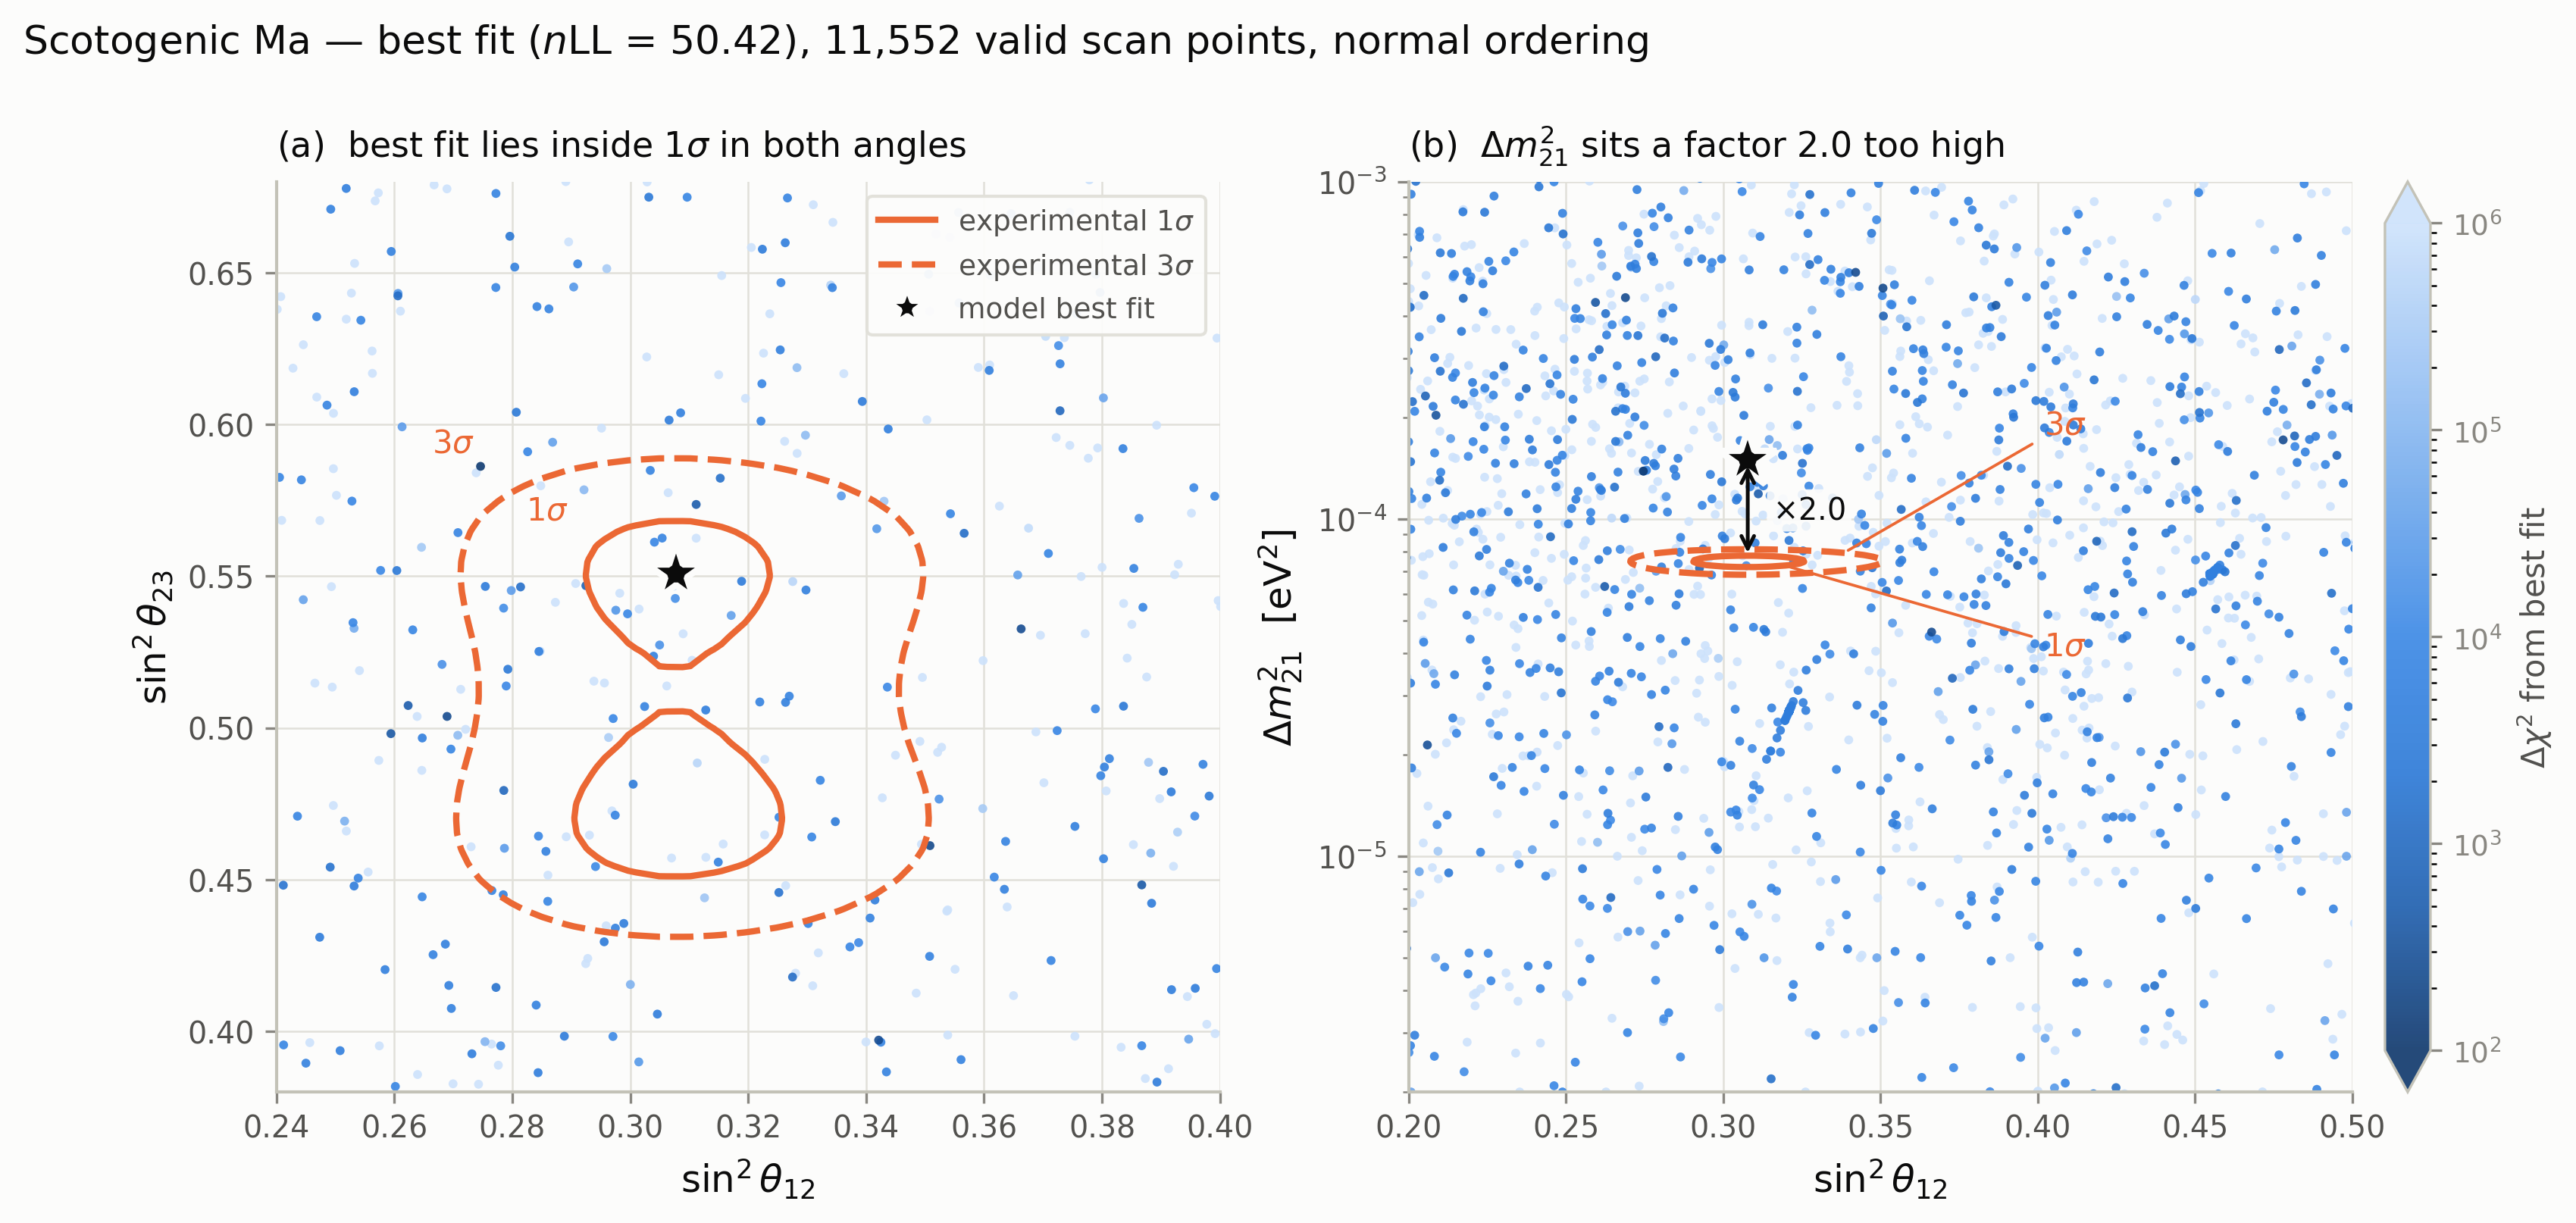

In [8]:
from IPython.display import Image, display
display(Image(filename="figures/scotogenic_panels.png"))

Best-fit oscillation observables and mass spectrum from the pooled valid-point sample.

## 6. Caveats

The NuFIT tabulated profiles are normal-ordering only and are not RGE-run; the dark-matter relic density and direct-detection rate are not part of this fit. `table_lookup` likelihoods use a cubic spline that can undershoot marginally below a table's tabulated minimum of zero -- numerically harmless here, worth noting if term-level values are quoted.

## 7. Reproducing the full study

The cell below is exactly the pattern used to produce the table in section 4 — shown, not executed, since a full matched-budget run can take a while.

In [ ]:
# NOT executed in this notebook (can take from seconds to several minutes per
# engine). Reproduces the matched-budget comparison from the study: seed
# 20260816, ~30k evaluations, one row per engine.
rows = []
for engine in ["serial_random", "de_scipy", "adaptive_diver", "basin_scan"]:
    m = load_model("../models/scotogenic_ma/model_no.yaml")
    m.scan.engine = engine
    m.scan.seed = 20260816
    m.scan.settings["max_evaluations"] = 30000
    c = compile_model(m)
    r = run_scan(m, c, run_directory=f"runs/{engine}_matched")
    rows.append({"engine": engine, **r.summary})
pd.DataFrame(rows)

---
BSMScanner: a declarative parameter-scanning framework for BSM physics. See the companion paper for the full seven-benchmark methodology study, and `notebooks/t43i_b1.ipynb` for a worked physics application built on top of it.